# SOB4ES - Comparador de Modelos con Clasificación Ordinal
### CRISP-ML(Q) - Fase 5: Evaluación y selección del modelo final

Este notebook extiende el comparador estándar (basado en R2, RMSE, MAE) añadiendo una
**perspectiva de clasificación ordinal**: las predicciones y los valores reales se convierten
en categorías discretas (Bajo / Medio / Alto) usando los percentiles 33 y 66 calculados
sobre el conjunto combinado `train + eval`.

Esto permite:
- Generar **matrices de confusión** por target y por modelo, mostrando no solo si el modelo
  acierta sino qué tipo de error comete (confunde Bajo con Medio, o Bajo con Alto).
- Calcular métricas de clasificación adicionales que complementan el R2:
  **Accuracy**, **Cohen's Kappa** y **F1-macro**.

**Datasets:** `train.csv` (para calcular umbrales), `eval.csv` (para evaluar modelos).

**Modelos comparados:** los 8 enfoques implementados en el proyecto.


## 1.- Configuración

Carga del entorno, librerías y variables globales base.

In [1]:
import os
import warnings
import joblib
import pandas as pd
import numpy as np
import itertools

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sns

import torch
import torch.nn as nn

from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    confusion_matrix, accuracy_score, cohen_kappa_score,
    f1_score, classification_report
)

warnings.filterwarnings('ignore')

DATA_DIR    = 'input/'
MODELS_BASE = 'output/models/'
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CLASES = ['Bajo', 'Medio', 'Alto']

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]

FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    #'cu_z',
    'k_z',
    'mo_z',
    #'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]

print('Configuracion cargada correctamente...')

# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)


Configuracion cargada correctamente...


## 2.- Carga de datos

Se cargan `train.csv` y `eval.csv`. Los percentiles 33 y 66 para la clasificación ordinal
se calculan sobre el **conjunto combinado train + eval**, garantizando que los umbrales
reflejen la distribución global del dataset y no solo la de un subconjunto.

El modelo **nunca ha visto `eval.csv`** durante el entrenamiento ni el tuning,
por lo que la evaluación sobre este conjunto es imparcial.


In [2]:
df_train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
df_eval  = pd.read_csv(os.path.join(DATA_DIR, 'eval.csv'))

X_eval  = df_eval[FEATURES_AUTORIZADAS]
y_eval  = df_eval[TARGETS]

# Conjunto combinado para calcular percentiles globales
df_combined = pd.concat([df_train[TARGETS], df_eval[TARGETS]], ignore_index=True)

print(f'train.csv  : {len(df_train)} filas')
print(f'eval.csv   : {len(df_eval)} filas')
print(f'Combinado  : {len(df_combined)} filas (para calculo de percentiles)')


train.csv  : 299 filas
eval.csv   : 65 filas
Combinado  : 364 filas (para calculo de percentiles)


## 3.- Cálculo de umbrales de clasificación

Cada target se divide en tres clases de igual tamaño aproximado usando los percentiles
33 y 66 calculados sobre `train + eval`:

| Clase | Criterio |
|---|---|
| **Bajo** | Valor ≤ percentil 33 |
| **Medio** | Percentil 33 < Valor ≤ percentil 66 |
| **Alto** | Valor > percentil 66 |

Este enfoque garantiza que cada clase represente aproximadamente un tercio del dataset
en el conjunto combinado, produciendo clases equilibradas y evitando que una clase
domine por tener un rango de valores mucho mas amplio que las otras.

Los umbrales se calculan una sola vez aqui y se reutilizan para todos los modelos.


In [3]:
# Calcular percentiles 33 y 66 por target sobre el conjunto combinado
umbrales = {}
for t in TARGETS:
    p33 = df_combined[t].quantile(0.33)
    p66 = df_combined[t].quantile(0.66)
    umbrales[t] = (p33, p66)

print('Umbrales de clasificacion (p33, p66) por target:')
print(f'  {"Target":30} {"p33":>8} {"p66":>8}')
print('-' * 50)
for t, (p33, p66) in umbrales.items():
    print(f'  {t:30} {p33:8.4f} {p66:8.4f}')


def clasificar(valores, target):
    """
    Convierte un array de valores continuos en clases ordinales
    (0=Bajo, 1=Medio, 2=Alto) usando los umbrales globales del target.
    """
    p33, p66 = umbrales[target]
    return np.where(valores <= p33, 0, np.where(valores <= p66, 1, 2))


Umbrales de clasificacion (p33, p66) por target:
  Target                              p33      p66
--------------------------------------------------
  nematode_shannon_z              -0.1869   0.5169
  macro_shannon_z                 -0.3214   0.6288
  earthworm_shannon_z              0.0299   0.4239
  orib_shannon_z                  -0.8646   0.5237
  meso_shannon_z                  -0.6420  -0.2622
  coll_shannon_z                  -0.6186  -0.6186
  bac_shannon_z                   -0.0287   0.3980
  fun_shannon_z                   -0.3097   0.4067
  euk_shannon_z                   -0.2973   0.3801
  oomy_shannon_z                  -0.2735   0.4768
  cerc_shannon_z                  -0.1777   0.3593
  macro_order_richness_z          -0.6013   0.2751
  earthworm_richness_z            -0.3821  -0.0079
  orib_species_richness_z         -0.7099   0.2322
  meso_species_richness_z         -0.7783   0.3988
  coll_species_richness_z         -0.6982  -0.1721
  bac_asv_richness_z             

## 4.- Métricas empleadas

Además del R2 estándar, se calculan las siguientes metricas sobre las clases ordinales.

Todas estan justificadas por su complementariedad con el R2 en contextos ecológicos donde interesa mas acertar la categoria de diversidad que el valor exacto:

- **R2 (coeficiente de determinacion) :** Mide qué proporción de la varianza real explica el modelo sobre los valores continuos.
Es la métrica principal de comparación entre modelos.
- **Accuracy (exactitud de clasificacion) :** Proporción de muestras en las que el modelo asigna correctamente la clase Bajo/Medio/Alto. Una accuracy aleatoria seria 0.33 (1 de cada 3 clases). Se usa como métrica base de clasificación, aunque puede ser engañosa si las clases no estan perfectamente equilibradas.
- **Cohen's Kappa :** Mide el acuerdo entre las clasificaciones del modelo y las reales, descontando el acuerdo que ocurriria por azar. Va de -1 a 1, donde 0 equivale a clasificacion aleatoria y 1 a acuerdo perfecto. Se usa aquí en su variante **ponderada lineal** (`weights='linear'`), que penaliza más los errores grandes (confundir Bajo con Alto) que los pequeños (confundir Bajo con Medio). Esta ponderación es especialmente adecuada para variables ordinales como las clases de diversidad biológica.
- **F1-macro :** Media del F1 calculado por separado para cada clase, sin ponderar por el tamaño de cada una. Captura el rendimiento del modelo en cada nivel de diversidad por igual, lo que es útil cuando nos interesa que el modelo funcione bien tanto para suelos de baja diversidad como para los de alta diversidad, sin que una clase mayoritaria enmascare los errores en las minoritarias.
- **Matriz de confusión :** Tabla 3x3 que muestra cuantas muestras de cada clase real fueron predichas en cada clase. Permite identificar el patrón de errores del modelo: si tiende a confundir Bajo con Medio (error leve) o Bajo con Alto (error grave). Es la visualización mas informativa para entender el comportamiento del clasificador.


## 5.- Funciones auxiliares

Funciones reutilizables para cargar modelos, generar predicciones y calcular todas las métricas sobre `eval.csv`.


In [4]:
def calcular_metricas(y_true_cont, y_pred_cont, target):
    """
    Calcula metricas continuas (R2, RMSE, MAE) y de clasificacion ordinal
    (Accuracy, Kappa ponderado, F1-macro) para un target dado.
    """
    r2   = r2_score(y_true_cont, y_pred_cont)
    rmse = np.sqrt(mean_squared_error(y_true_cont, y_pred_cont))
    mae  = mean_absolute_error(y_true_cont, y_pred_cont)

    y_true_cls = clasificar(y_true_cont, target)
    y_pred_cls = clasificar(y_pred_cont, target)

    acc   = accuracy_score(y_true_cls, y_pred_cls)
    kappa = cohen_kappa_score(y_true_cls, y_pred_cls, weights='linear')
    f1    = f1_score(y_true_cls, y_pred_cls, average='macro', zero_division=0)
    cm    = confusion_matrix(y_true_cls, y_pred_cls, labels=[0, 1, 2])

    return {
        'r2': round(r2, 4), 'rmse': round(rmse, 4), 'mae': round(mae, 4),
        'accuracy': round(acc, 4), 'kappa': round(kappa, 4), 'f1_macro': round(f1, 4),
        'confusion_matrix': cm,
        'y_true_cls': y_true_cls, 'y_pred_cls': y_pred_cls
    }


def metricas_globales(y_true_mat, y_pred_mat, nombre):
    """
    Calcula metricas globales (promedio sobre los 21 targets) para un modelo.
    Devuelve un dict con las medias y la lista de metricas por target.
    """
    resultados_por_target = {}
    for i, t in enumerate(TARGETS):
        resultados_por_target[t] = calcular_metricas(
            y_true_mat[:, i], y_pred_mat[:, i], t
        )

    r2_global      = np.mean([v['r2']       for v in resultados_por_target.values()])
    acc_global     = np.mean([v['accuracy']  for v in resultados_por_target.values()])
    kappa_global   = np.mean([v['kappa']     for v in resultados_por_target.values()])
    f1_global      = np.mean([v['f1_macro']  for v in resultados_por_target.values()])
    rmse_global    = np.mean([v['rmse']      for v in resultados_por_target.values()])

    return {
        'modelo': nombre,
        'r2_global': round(r2_global, 4),
        'accuracy_global': round(acc_global, 4),
        'kappa_global': round(kappa_global, 4),
        'f1_global': round(f1_global, 4),
        'rmse_global': round(rmse_global, 4),
        'por_target': resultados_por_target
    }


def predecir_pkl_individual(carpeta, fn_nombre, n, X):
    """Carga n modelos individuales (uno por target) y devuelve matriz (n_eval x n_targets)."""
    y_pred = np.zeros((len(X), len(TARGETS)))
    for j, t in enumerate(TARGETS):
        preds = [joblib.load(os.path.join(MODELS_BASE, carpeta, fn_nombre(t, i))).predict(X)
                 for i in range(n)]
        y_pred[:, j] = np.mean(preds, axis=0)
    return y_pred


def predecir_pkl_multi(carpeta, prefijo, sufijo, n, X):
    """Carga n modelos multisalida y devuelve el promedio de predicciones."""
    preds = [joblib.load(os.path.join(MODELS_BASE, carpeta, f'{prefijo}{i}{sufijo}.pkl')).predict(X)
             for i in range(n)]
    return np.mean(preds, axis=0)


class MLPMultiSalida(nn.Module):
    def __init__(self, n_inputs, n_outputs, hidden_sizes, dropout_rate):
        super().__init__()
        layers, in_size = [], n_inputs
        for h in hidden_sizes:
            layers += [nn.Linear(in_size, h), nn.ReLU(), nn.Dropout(dropout_rate)]
            in_size = h
        layers.append(nn.Linear(in_size, n_outputs))
        self.red = nn.Sequential(*layers)
    def forward(self, x): return self.red(x)


def predecir_mlp(carpeta, prefijo, n, X, config_file):
    """Carga n redes PyTorch y devuelve el promedio de predicciones."""
    cfg   = joblib.load(os.path.join(MODELS_BASE, carpeta, config_file))
    X_t   = torch.tensor(X.values, dtype=torch.float32).to(DEVICE)
    preds = []
    for i in range(n):
        model = MLPMultiSalida(X.shape[1], len(TARGETS), cfg['hidden'], cfg['dropout']).to(DEVICE)
        model.load_state_dict(torch.load(
            os.path.join(MODELS_BASE, carpeta, f'{prefijo}{i}.pt'), map_location=DEVICE
        ))
        model.eval()
        with torch.no_grad():
            preds.append(model(X_t).cpu().numpy())
    return np.mean(preds, axis=0)


print('Funciones auxiliares definidas.')


Funciones auxiliares definidas.


## 6.- Predicciones de cada modelo

Se cargan todos los modelos desde disco y se generan predicciones sobre `eval.csv`.

Las predicciones son siempre valores continuos; la conversion a clases ordinales se realiza dentro de `calcular_metricas` usando los umbrales de la sección 3.


In [5]:
resultados = {}
y_true_mat = y_eval.values

print('Cargando modelos y generando predicciones...\n')

# 1. Random Forest individual
print('  [1/8] Random Forest individual...')
y_pred = predecir_pkl_individual('rf', lambda t, i: f'rf_prod_{t}_m{i}.pkl', 5, X_eval)
resultados['RF Individual'] = metricas_globales(y_true_mat, y_pred, 'RF Individual')

# 2. XGBoost individual
print('  [2/8] XGBoost individual...')
y_pred = predecir_pkl_individual('xgb', lambda t, i: f'xgb_prod_{t}_exp{i}.pkl', 5, X_eval)
resultados['XGBoost Individual'] = metricas_globales(y_true_mat, y_pred, 'XGBoost Individual')

# 3. Ridge individual
print('  [3/8] Ridge Regression...')
y_pred_ridge = np.zeros((len(X_eval), len(TARGETS)))
for j, t in enumerate(TARGETS):
    m = joblib.load(os.path.join(MODELS_BASE, 'reg', f'ridge_prod_{t}.pkl'))
    y_pred_ridge[:, j] = m.predict(X_eval)
resultados['Ridge'] = metricas_globales(y_true_mat, y_pred_ridge, 'Ridge')

# 4. RF multisalida
print('  [4/8] Random Forest multisalida...')
y_pred = predecir_pkl_multi('rf_multi', 'rf_multi_m', '', 5, X_eval)
resultados['RF Multisalida'] = metricas_globales(y_true_mat, y_pred, 'RF Multisalida')

# 5. XGBoost multisalida
print('  [5/8] XGBoost multisalida...')
y_pred = predecir_pkl_multi('xgb_multi', 'xgb_multi_exp', '', 5, X_eval)
resultados['XGBoost Multisalida'] = metricas_globales(y_true_mat, y_pred, 'XGBoost Multisalida')

# 6. RegressorChain
print('  [6/8] Ensemble RegressorChain...')
N_CHAINS    = 10
preds_chain = [joblib.load(os.path.join(MODELS_BASE, 'chain', f'chain_{i}.pkl')).predict(X_eval)
               for i in range(N_CHAINS)]
y_pred = np.mean(preds_chain, axis=0)
resultados['RegressorChain'] = metricas_globales(y_true_mat, y_pred, 'RegressorChain')

# 7. MLP estandar
print('  [7/8] MLP Multisalida estandar...')
y_pred = predecir_mlp('mlp', 'mlp_prod_', 5, X_eval, 'mlp_config.pkl')
resultados['MLP Estandar'] = metricas_globales(y_true_mat, y_pred, 'MLP Estandar')

# 8. MLP perdida personalizada
print('  [8/8] MLP perdida personalizada...')
y_pred = predecir_mlp('mlp_custom', 'mlp_custom_', 5, X_eval, 'mlp_custom_config.pkl')
resultados['MLP Custom'] = metricas_globales(y_true_mat, y_pred, 'MLP Custom')

print('\nPredicciones completadas.')


Cargando modelos y generando predicciones...

  [1/8] Random Forest individual...


  [2/8] XGBoost individual...


  [3/8] Ridge Regression...
  [4/8] Random Forest multisalida...


  [5/8] XGBoost multisalida...


  [6/8] Ensemble RegressorChain...


  [7/8] MLP Multisalida estandar...
  [8/8] MLP perdida personalizada...

Predicciones completadas.


## 7.- Tabla comparativa global

Se muestran todas las métricas globales (promedio sobre los 21 targets) para cada modelo, ordenadas por R2 descendente.

Guía de interpretacion:
- **R2:** que proporción de la varianza real explica el modelo (cuanto mas cerca de 1, mejor).
- **Accuracy:** proporción de muestras clasificadas correctamente en Bajo/Medio/Alto. El azar da 0.33.
- **Kappa ponderado:** acuerdo con los valores reales descontando el azar, penalizando mas los errores graves (Bajo ↔ Alto).
- **F1-macro:** equilibrio entre precisión y recall promediado por igual entre las tres clases.
- **RMSE:** error cuadrático medio sobre los valores continuos.


In [6]:
tabla = pd.DataFrame([{
    'Modelo':    r['modelo'],
    'R2':        r['r2_global'],
    'Accuracy':  r['accuracy_global'],
    'Kappa':     r['kappa_global'],
    'F1-macro':  r['f1_global'],
    'RMSE':      r['rmse_global'],
} for r in resultados.values()]).sort_values('R2', ascending=False).reset_index(drop=True)

tabla.index += 1
print('Comparacion de modelos (ordenado por R2 descendente):')
print('=' * 75)
print(tabla.to_string())
print('=' * 75)
print(f'\nMejor modelo por R2       : {tabla.iloc[0]["Modelo"]} ({tabla.iloc[0]["R2"]})')
print(f'Mejor modelo por Kappa    : {tabla.sort_values("Kappa", ascending=False).iloc[0]["Modelo"]}')
print(f'Mejor modelo por F1-macro : {tabla.sort_values("F1-macro", ascending=False).iloc[0]["Modelo"]}')


Comparacion de modelos (ordenado por R2 descendente):
                Modelo      R2  Accuracy   Kappa  F1-macro    RMSE
1       RF Multisalida  0.0968    0.3832  0.1322    0.3035  0.9071
2        RF Individual  0.0866    0.4007  0.1704    0.3485  0.9054
3  XGBoost Multisalida  0.0804    0.4352  0.2309    0.4052  0.9036
4       RegressorChain  0.0758    0.4007  0.1803    0.3553  0.9077
5   XGBoost Individual  0.0671    0.4044  0.1699    0.3478  0.9165
6         MLP Estandar -0.0098    0.3927  0.1543    0.3270  0.9381
7                Ridge -0.0133    0.3744  0.1144    0.3063  0.9567
8           MLP Custom -0.0200    0.4000  0.1611    0.3477  0.9419

Mejor modelo por R2       : RF Multisalida (0.0968)
Mejor modelo por Kappa    : XGBoost Multisalida
Mejor modelo por F1-macro : XGBoost Multisalida


## 8.- Métricas por target

Tabla detallada con R2, Accuracy, Kappa y F1-macro para cada uno de los 21 targets y cada modelo. 

Permite identificar en qué grupos biológicos falla cada enfoque y si los errores son de tipo leve (Bajo ↔ Medio) o grave (Bajo ↔ Alto).


In [7]:
METRICA_KEYS = {
    'r2':       'r2_global',
    'accuracy': 'accuracy_global',
    'kappa':    'kappa_global',
    'f1_macro': 'f1_global',
}

for metrica, key_global in METRICA_KEYS.items():
    filas = []
    for nombre, res in resultados.items():
        filas.append({'Target': 'GLOBAL', 'Modelo': nombre,
                      'Valor': res[key_global]})
        for t in TARGETS:
            filas.append({'Target': t, 'Modelo': nombre,
                          'Valor': res['por_target'][t][metrica]})

    df_m = pd.DataFrame(filas).pivot(index='Target', columns='Modelo', values='Valor')
    orden_cols = tabla['Modelo'].tolist()
    df_m = df_m[orden_cols]
    orden_rows = ['GLOBAL'] + TARGETS
    df_m = df_m.loc[orden_rows]

    print(f'\n{metrica.upper()} por target:')
    print('=' * 120)
    print(df_m.round(3).to_string())
    print('=' * 120)


R2 por target:
Modelo                   RF Multisalida  RF Individual  XGBoost Multisalida  RegressorChain  XGBoost Individual  MLP Estandar  Ridge  MLP Custom
Target                                                                                                                                          
GLOBAL                            0.097          0.087                0.080           0.076               0.067        -0.010 -0.013      -0.020
nematode_shannon_z                0.151          0.134                0.216           0.135               0.146         0.046 -0.002       0.056
macro_shannon_z                   0.197          0.314                0.380           0.276               0.258         0.194  0.119       0.209
earthworm_shannon_z               0.425          0.512                0.533           0.485               0.495         0.355  0.244       0.384
orib_shannon_z                    0.168          0.189                0.224           0.202               0.150   

## 9.- Matrices de confusión

Para cada modelo se muestra la matriz de confusión agregada: suma de las 21 matrices individuales (una por target), normalizada por filas para mostrar proporciones.

La diagonal principal representa los aciertos. Los elementos fuera de la diagonal muestran el tipo de error: los errores en la subdiagonal o superdiagonal inmediata (Bajo ↔ Medio o Medio ↔ Alto) son errores leves, mientras que los errores en las esquinas (Bajo ↔ Alto) son errores graves que el Kappa ponderado penaliza mas.

Se muestran adicionalmente las matrices de confusión individuales para los dos targets de referencia (earthworm_shannon_z y earthworm_richness_z).


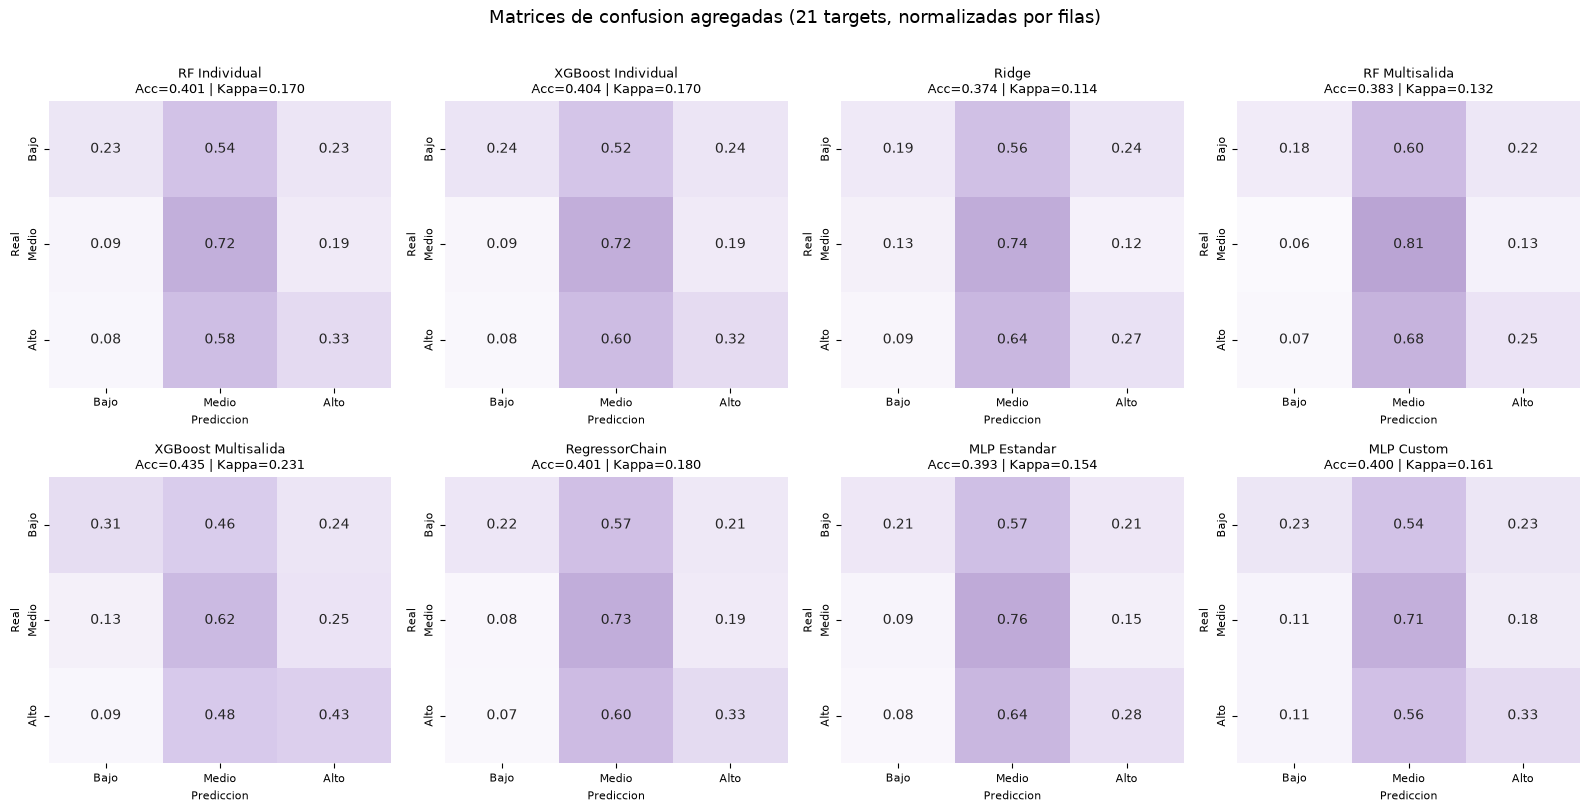

In [8]:
# Matrices de confusion agregadas (suma de los 21 targets, normalizada por filas)
n_modelos = len(resultados)
n_cols    = 4
n_rows    = (n_modelos + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for idx, (nombre, res) in enumerate(resultados.items()):
    cm_agg = np.zeros((3, 3), dtype=int)
    for t in TARGETS:
        cm_agg += res['por_target'][t]['confusion_matrix']

    cm_norm = cm_agg.astype(float) / cm_agg.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, ax=axes[idx], annot=True, fmt='.2f', cmap=PALETTE_CMAP,
                xticklabels=CLASES, yticklabels=CLASES,
                vmin=0, vmax=1, cbar=False)
    axes[idx].set_title(f'{nombre}\nAcc={res["accuracy_global"]:.3f} | Kappa={res["kappa_global"]:.3f}',
                        fontsize=9)
    axes[idx].set_xlabel('Prediccion', fontsize=8)
    axes[idx].set_ylabel('Real', fontsize=8)
    axes[idx].tick_params(labelsize=8)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Matrices de confusion agregadas (21 targets, normalizadas por filas)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


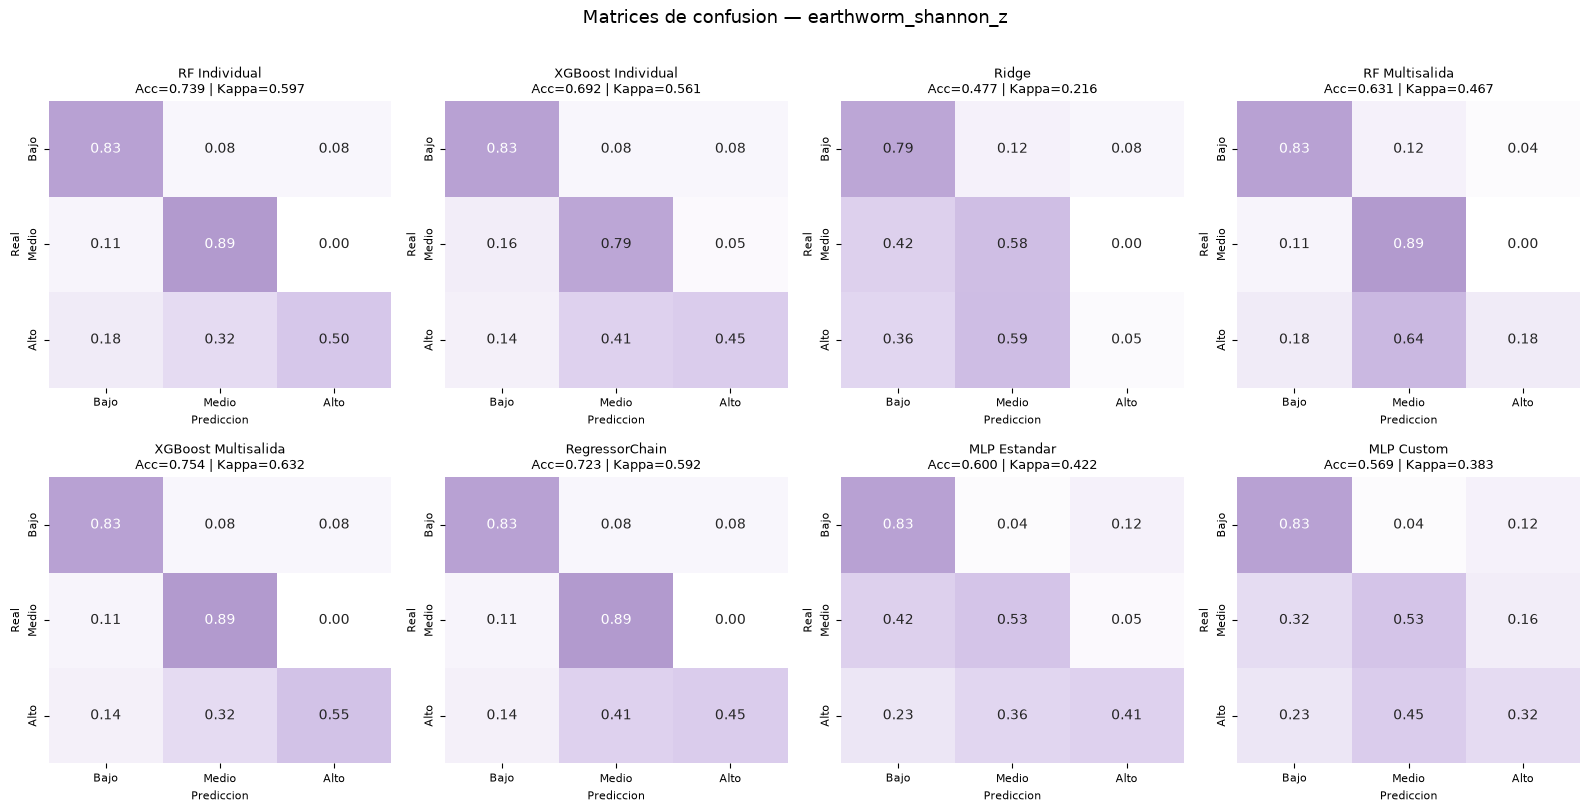

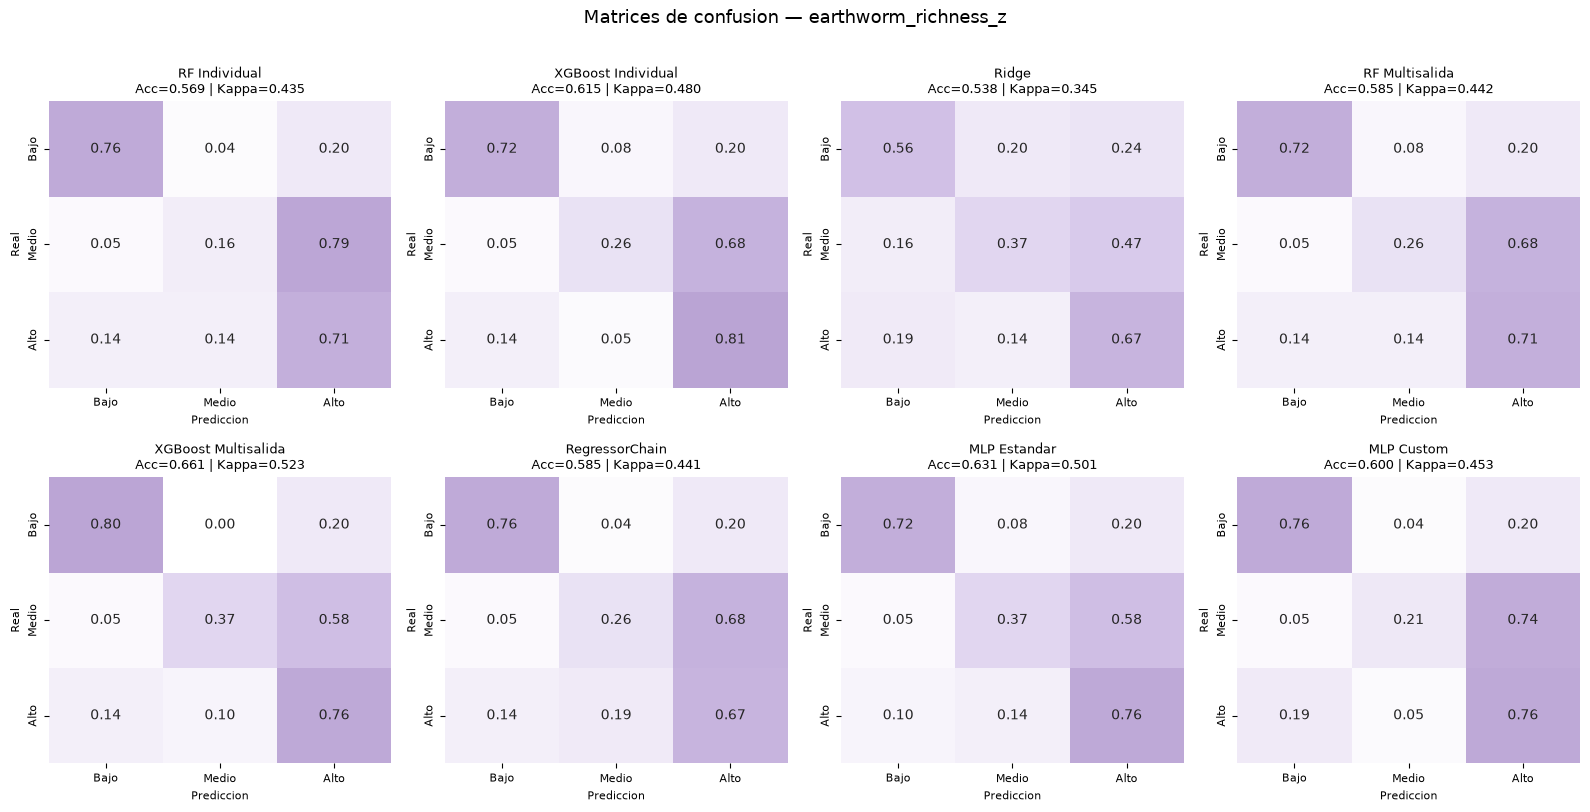

In [9]:
# Matrices de confusion individuales para los dos targets de referencia
for ref_target in ['earthworm_shannon_z', 'earthworm_richness_z']:
    n_modelos = len(resultados)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for idx, (nombre, res) in enumerate(resultados.items()):
        cm = res['por_target'][ref_target]['confusion_matrix']
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

        sns.heatmap(cm_norm, ax=axes[idx], annot=True, fmt='.2f', cmap=PALETTE_CMAP,
                    xticklabels=CLASES, yticklabels=CLASES,
                    vmin=0, vmax=1, cbar=False)
        kappa_t = res['por_target'][ref_target]['kappa']
        acc_t   = res['por_target'][ref_target]['accuracy']
        axes[idx].set_title(f'{nombre}\nAcc={acc_t:.3f} | Kappa={kappa_t:.3f}', fontsize=9)
        axes[idx].set_xlabel('Prediccion', fontsize=8)
        axes[idx].set_ylabel('Real', fontsize=8)
        axes[idx].tick_params(labelsize=8)

    plt.suptitle(f'Matrices de confusion — {ref_target}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


## 10.- Visualización comparativa de métricas

Gráficos de barras comparando todos los modelos en las cuatro métricas principales para facilitar la seleccion visual del mejor enfoque.


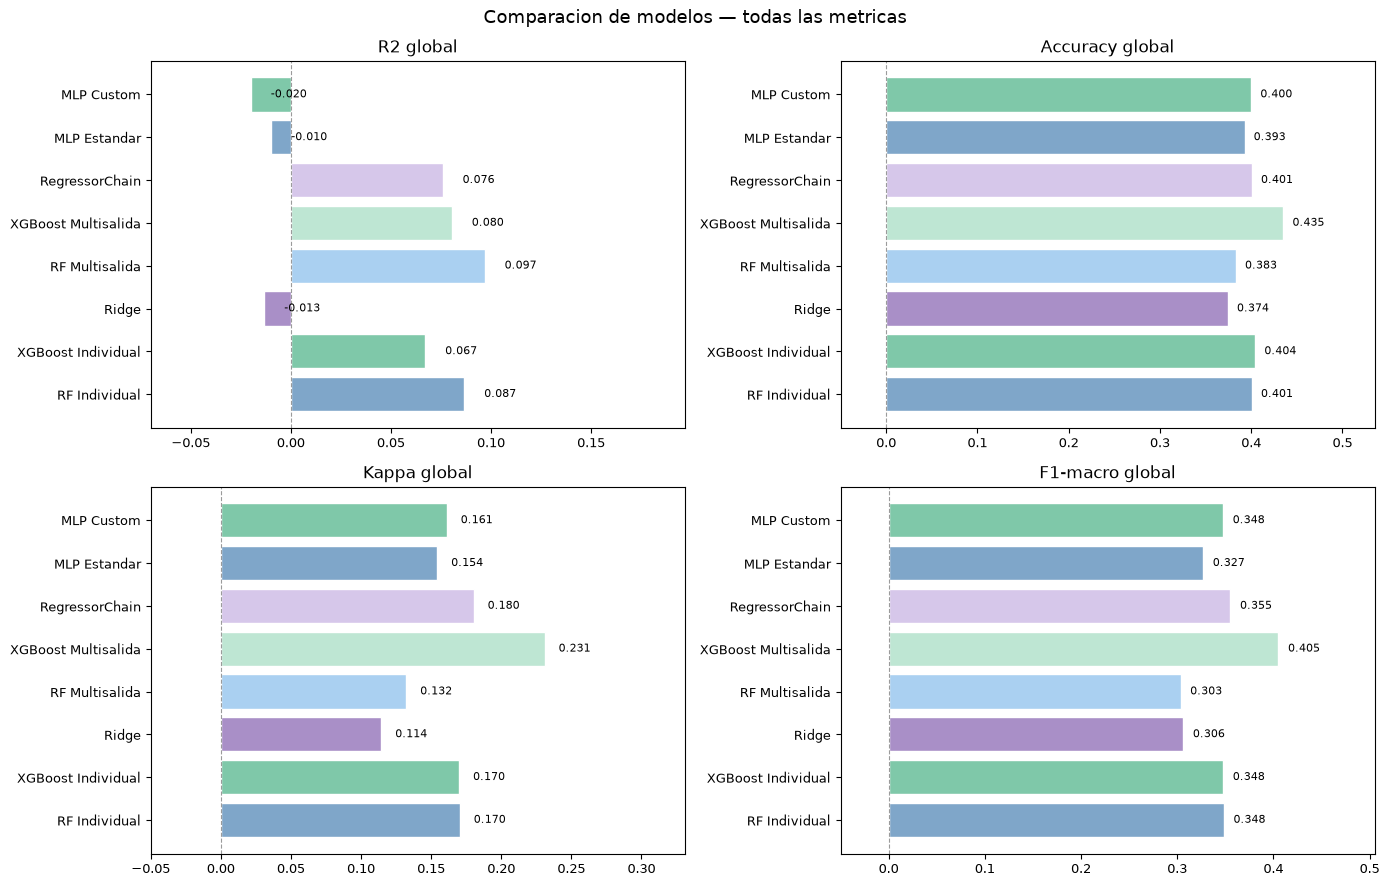

In [10]:
metricas_plot = {
    'R2 global':       [r['r2_global']       for r in resultados.values()],
    'Accuracy global': [r['accuracy_global']  for r in resultados.values()],
    'Kappa global':    [r['kappa_global']     for r in resultados.values()],
    'F1-macro global': [r['f1_global']        for r in resultados.values()],
}
nombres = list(resultados.keys())
colores = palette_cycle(len(nombres))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (titulo, valores) in zip(axes, metricas_plot.items()):
    bars = ax.barh(nombres, valores, color=colores, edgecolor='white')
    ax.set_title(titulo, fontsize=12)
    ax.set_xlim(min(0, min(valores)) - 0.05, max(valores) + 0.1)
    ax.axvline(0, color=PALETTE['gray'], linewidth=0.8, linestyle='--')
    for bar, val in zip(bars, valores):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.tick_params(labelsize=9)

plt.suptitle('Comparacion de modelos — todas las metricas', fontsize=13)
plt.tight_layout()
plt.show()


## 11.- Exportación de resultados

Se guardan las tablas comparativas en CSV para uso externo.


In [11]:
os.makedirs('output/clasificacion', exist_ok=True)

tabla.to_csv('output/clasificacion/comparacion_global.csv', index=False)

# Tabla R2 por target
filas_r2 = []
for nombre, res in resultados.items():
    filas_r2.append({'Target': 'GLOBAL', 'Modelo': nombre, 'R2': res['r2_global']})
    for t in TARGETS:
        filas_r2.append({'Target': t, 'Modelo': nombre, 'R2': res['por_target'][t]['r2']})

pd.DataFrame(filas_r2).pivot(index='Target', columns='Modelo', values='R2') \
    .to_csv('output/clasificacion/r2_por_target.csv')

# Tabla Kappa por target
filas_k = []
for nombre, res in resultados.items():
    filas_k.append({'Target': 'GLOBAL', 'Modelo': nombre, 'Kappa': res['kappa_global']})
    for t in TARGETS:
        filas_k.append({'Target': t, 'Modelo': nombre, 'Kappa': res['por_target'][t]['kappa']})

pd.DataFrame(filas_k).pivot(index='Target', columns='Modelo', values='Kappa') \
    .to_csv('output/clasificacion/kappa_por_target.csv')

print('Resultados exportados:')
print('  output/clasificacion/comparacion_global.csv')
print('  output/clasificacion/r2_por_target.csv')
print('  output/clasificacion/kappa_por_target.csv')


Resultados exportados:
  output/clasificacion/comparacion_global.csv
  output/clasificacion/r2_por_target.csv
  output/clasificacion/kappa_por_target.csv


Generando análisis radial individualizado por modelo...


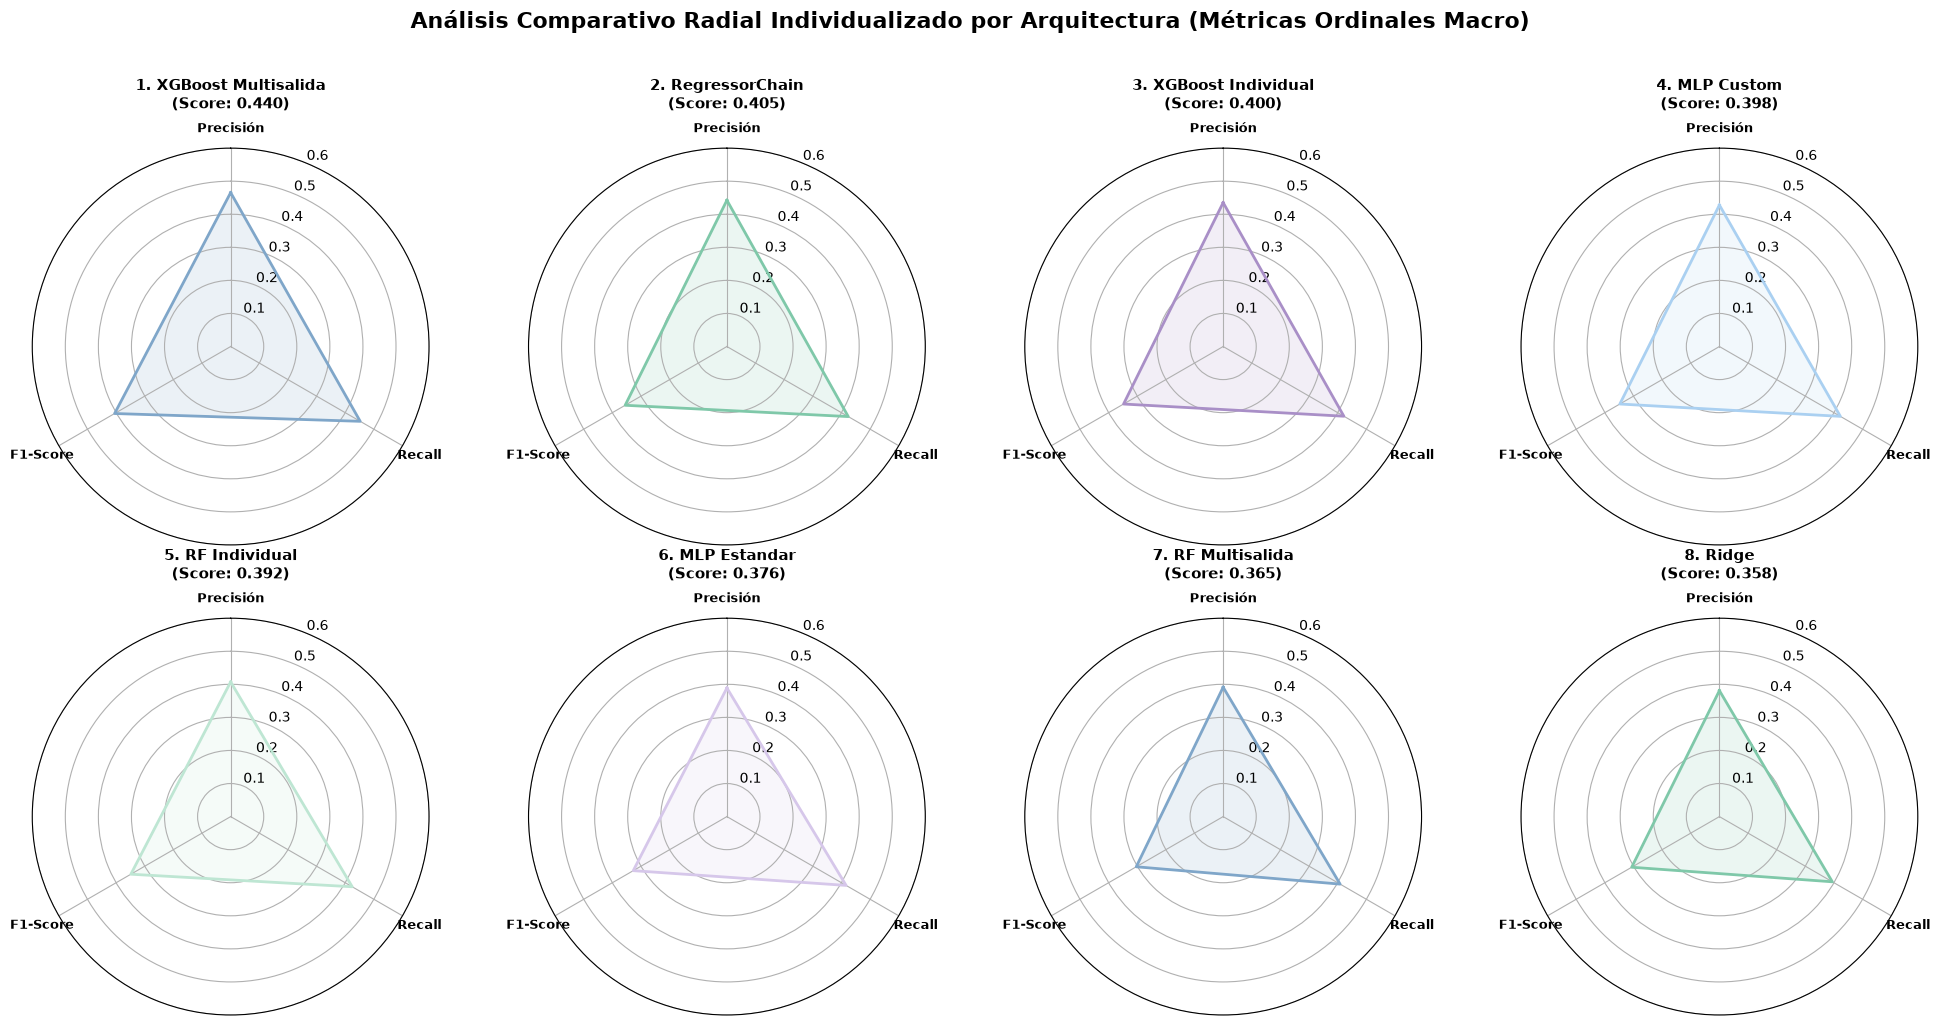

Top 8 modelos (Métricas de Clasificación Ordinal)

Top 1: XGBoost Multisalida                 | Compuesto: 0.4402 | F1: 0.4052 | P: 0.4655 | R: 0.4524
Top 2: RegressorChain                      | Compuesto: 0.4053 | F1: 0.3553 | P: 0.4424 | R: 0.4237
Top 3: XGBoost Individual                  | Compuesto: 0.3996 | F1: 0.3478 | P: 0.4351 | R: 0.4216
Top 4: MLP Custom                          | Compuesto: 0.3976 | F1: 0.3477 | P: 0.4279 | R: 0.4224
Top 5: RF Individual                       | Compuesto: 0.3921 | F1: 0.3485 | P: 0.4074 | R: 0.4245
Top 6: MLP Estandar                        | Compuesto: 0.3755 | F1: 0.3270 | P: 0.3890 | R: 0.4163
Top 7: RF Multisalida                      | Compuesto: 0.3647 | F1: 0.3035 | P: 0.3912 | R: 0.4084
Top 8: Ridge                               | Compuesto: 0.3584 | F1: 0.3063 | P: 0.3810 | R: 0.3943


In [12]:
from sklearn.metrics import precision_score, recall_score

print("Generando análisis radial individualizado por modelo...")

os.makedirs('output/clasificacion/graphs', exist_ok=True)

# 1. Extracción de métricas por modelo
filas_radar = []
for nombre, res in resultados.items():
    prec_targets, rec_targets = [], []
    for t in TARGETS:
        y_true_cls = res['por_target'][t]['y_true_cls']
        y_pred_cls = res['por_target'][t]['y_pred_cls']
        prec_targets.append(precision_score(y_true_cls, y_pred_cls, average='macro', zero_division=0))
        rec_targets.append(recall_score(y_true_cls, y_pred_cls, average='macro', zero_division=0))
        
    f1 = res['f1_global']
    precision = np.mean(prec_targets)
    recall = np.mean(rec_targets)
    
    # Puntuación compuesta para el orden del ranking (Media geométrica equilibrada)
    score_compuesto = (precision * recall * f1) ** (1/3)
    
    # Cambiamos 'F1-Score' por 'F1_Score' para evitar conflictos en itertuples()
    filas_radar.append({
        'Modelo': nombre,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'Score_Compuesto': score_compuesto
    })

df_radar_individual = pd.DataFrame(filas_radar).sort_values(by='Score_Compuesto', ascending=False)

# 2. Configuración de la visualización radial conjunta (Matriz 2x4)
categorias = ['Precision', 'Recall', 'F1_Score']
num_vars = len(categorias)
angulos = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angulos += angulos[:1]

fig, axes = plt.subplots(2, 4, figsize=(20, 10), subplot_kw=dict(polar=True))
axes = axes.flatten()
colores = palette_cycle(len(df_radar_individual))

for idx, fila in df_radar_individual.reset_index(drop=True).iterrows():
    ax = axes[idx]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    valores = [fila['Precision'], fila['Recall'], fila['F1_Score']]
    valores += valores[:1]
    
    # Dibujar polígono en la cuadrícula general
    ax.plot(angulos, valores, color=colores[idx], linewidth=2, label=fila['Modelo'])
    ax.fill(angulos, valores, color=colores[idx], alpha=0.15)
    
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(['Precisión', 'Recall', 'F1-Score'], fontsize=9, fontweight='bold')
    ax.set_ylim(0, 0.6)  # Ajustar según tus límites de datos reales
    ax.set_title(f"{idx+1}. {fila['Modelo']}\n(Score: {fila['Score_Compuesto']:.3f})", fontsize=11, fontweight='bold', pad=10)
    
    # Guardar también como gráfico independiente para la memoria escrita
    fig_ind, ax_ind = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
    ax_ind.set_theta_offset(np.pi / 2)
    ax_ind.set_theta_direction(-1)
    ax_ind.plot(angulos, valores, color=colores[idx], linewidth=2.5)
    ax_ind.fill(angulos, valores, color=colores[idx], alpha=0.2)
    ax_ind.set_xticks(angulos[:-1])
    ax_ind.set_xticklabels(['Precisión', 'Recall', 'F1-Score'], fontsize=10, fontweight='bold')
    ax_ind.set_ylim(0, 0.6)
    ax_ind.set_title(f"Perfil de Calidad: {fila['Modelo']}", fontsize=12, fontweight='bold')
    fig_ind.tight_layout()
    nombre_archivo = f"output/clasificacion/graphs/radar_{fila['Modelo'].lower().replace(' ', '_')}.png"
    fig_ind.savefig(nombre_archivo, dpi=300)
    plt.close(fig_ind)

# Ajustar y guardar el mosaico general
fig.suptitle("Análisis Comparativo Radial Individualizado por Arquitectura (Métricas Ordinales Macro)", fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('output/clasificacion/graphs/mosaico_radar_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Imprimir el Top 8 oficial con identificadores válidos r.F1_Score (S mayúscula)

print("Top 8 modelos (Métricas de Clasificación Ordinal)\n")

for i, r in enumerate(df_radar_individual.itertuples(), 1):
    print(f"Top {i}: {r.Modelo:<35} | Compuesto: {r.Score_Compuesto:.4f} | F1: {r.F1_Score:.4f} | P: {r.Precision:.4f} | R: {r.Recall:.4f}")


